# Backpropagation

## Learning Objectives

1. **Model** a neural network computation as a DAG (compute graph) with scalar or tensor nodes
2. **Define** the Jacobian $J_x(y) = \partial y / \partial x$ and apply the chain rule
3. **State** the backprop recurrence: $g(a) = J_a(b)^\top g(b)$ where $g(a) = \partial L/\partial a$
4. **Derive** gradients for fully connected layers: $\partial L/\partial W = \delta \cdot h^\top$, $\partial L/\partial h = W^\top \delta$
5. **Implement** backprop from scratch and verify against numerical gradients
6. **Explain** mini-batch SGD and the role of tensors in vectorising the computation


## Problem Statement

Training a neural network requires computing $\partial L / \partial \theta$ for every parameter $\theta$. Doing this naively (one parameter at a time with finite differences) costs $O(|\theta|)$ forward passes — too expensive for millions of parameters.

**Backpropagation** (Rumelhart, Hinton & Williams, 1986) computes all gradients in a **single backward pass** of the same cost as the forward pass, by reusing intermediate results via the chain rule on a compute graph.

### Compute Graph

Represent the computation $L = f(x_1, x_2, \ldots)$ as a DAG where:
- **Leaf nodes** are inputs and parameters
- **Internal nodes** are intermediate results
- **Edges** encode functional dependencies

The forward pass evaluates each node; the backward pass propagates gradients from the loss $L$ back through all nodes.

### Chain Rule in Matrix Form

For a composition $z = f(y),\ y = g(x)$:
$$\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial x} = J_x(y)^\top \nabla_y z$$

The **gradient accumulation rule** at each node $a$ with output $b = f(a)$:
$$g(a) := \frac{\partial L}{\partial a} = J_a(b)^\top g(b)$$


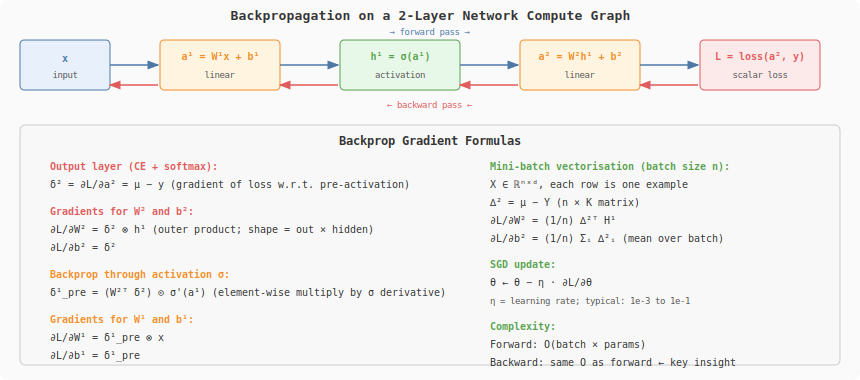

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="380" font-family="monospace" font-size="11">
  <rect width="860" height="380" fill="#fafafa" rx="8"/>
  <defs><marker id="fa" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#4e79a7"/></marker>
        <marker id="ba" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#e05c5c"/></marker></defs>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Backpropagation on a 2-Layer Network Compute Graph</text>

  <!-- Layer boxes -->
  <!-- Input -->
  <rect x="20"  y="40" width="90" height="50" rx="4" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="65"  y="62" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">x</text>
  <text x="65"  y="78" text-anchor="middle" fill="#555" font-size="9">input</text>

  <!-- FC1: a1 = W1·x + b1 -->
  <rect x="160" y="40" width="120" height="50" rx="4" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="220" y="60" text-anchor="middle" fill="#f28e2b" font-size="10" font-weight="bold">a¹ = W¹x + b¹</text>
  <text x="220" y="78" text-anchor="middle" fill="#555" font-size="9">linear</text>

  <!-- Activation h1 -->
  <rect x="340" y="40" width="120" height="50" rx="4" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="400" y="60" text-anchor="middle" fill="#59a14f" font-size="10" font-weight="bold">h¹ = σ(a¹)</text>
  <text x="400" y="78" text-anchor="middle" fill="#555" font-size="9">activation</text>

  <!-- FC2: a2 = W2·h1 + b2 -->
  <rect x="520" y="40" width="120" height="50" rx="4" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="580" y="60" text-anchor="middle" fill="#f28e2b" font-size="10" font-weight="bold">a² = W²h¹ + b²</text>
  <text x="580" y="78" text-anchor="middle" fill="#555" font-size="9">linear</text>

  <!-- Output -->
  <rect x="700" y="40" width="120" height="50" rx="4" fill="#fce9e9" stroke="#e05c5c"/>
  <text x="760" y="60" text-anchor="middle" fill="#e05c5c" font-size="10" font-weight="bold">L = loss(a², y)</text>
  <text x="760" y="78" text-anchor="middle" fill="#555" font-size="9">scalar loss</text>

  <!-- Forward arrows -->
  <line x1="110" y1="65" x2="158" y2="65" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#fa)"/>
  <line x1="280" y1="65" x2="338" y2="65" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#fa)"/>
  <line x1="460" y1="65" x2="518" y2="65" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#fa)"/>
  <line x1="640" y1="65" x2="698" y2="65" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#fa)"/>
  <text x="430" y="35" text-anchor="middle" fill="#4e79a7" font-size="9">→ forward pass →</text>

  <!-- Backward arrows -->
  <line x1="698" y1="85" x2="640" y2="85" stroke="#e05c5c" stroke-width="1.5" marker-end="url(#ba)"/>
  <line x1="518" y1="85" x2="460" y2="85" stroke="#e05c5c" stroke-width="1.5" marker-end="url(#ba)"/>
  <line x1="338" y1="85" x2="280" y2="85" stroke="#e05c5c" stroke-width="1.5" marker-end="url(#ba)"/>
  <line x1="158" y1="85" x2="110" y2="85" stroke="#e05c5c" stroke-width="1.5" marker-end="url(#ba)"/>
  <text x="430" y="108" text-anchor="middle" fill="#e05c5c" font-size="9">← backward pass ←</text>

  <!-- Gradient formulas -->
  <rect x="20" y="125" width="820" height="240" rx="5" fill="#f8f8f8" stroke="#ccc"/>
  <text x="430" y="145" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">Backprop Gradient Formulas</text>

  <!-- Column 1: output layer -->
  <text x="50" y="170" fill="#e05c5c" font-size="10" font-weight="bold">Output layer (CE + softmax):</text>
  <text x="50" y="188" fill="#333" font-size="10">δ² = ∂L/∂a² = μ − y   (gradient of loss w.r.t. pre-activation)</text>

  <text x="50" y="215" fill="#e05c5c" font-size="10" font-weight="bold">Gradients for W² and b²:</text>
  <text x="50" y="233" fill="#333" font-size="10">∂L/∂W² = δ² ⊗ h¹   (outer product; shape = out × hidden)</text>
  <text x="50" y="251" fill="#333" font-size="10">∂L/∂b² = δ²</text>

  <text x="50" y="278" fill="#f28e2b" font-size="10" font-weight="bold">Backprop through activation σ:</text>
  <text x="50" y="296" fill="#333" font-size="10">δ¹_pre = (W²ᵀ δ²) ⊙ σ'(a¹)   (element-wise multiply by σ derivative)</text>

  <text x="50" y="323" fill="#f28e2b" font-size="10" font-weight="bold">Gradients for W¹ and b¹:</text>
  <text x="50" y="341" fill="#333" font-size="10">∂L/∂W¹ = δ¹_pre ⊗ x</text>
  <text x="50" y="359" fill="#333" font-size="10">∂L/∂b¹ = δ¹_pre</text>

  <!-- Column 2: mini-batch note -->
  <text x="490" y="170" fill="#59a14f" font-size="10" font-weight="bold">Mini-batch vectorisation (batch size n):</text>
  <text x="490" y="188" fill="#333" font-size="10">X ∈ ℝⁿˣᵈ, each row is one example</text>
  <text x="490" y="206" fill="#333" font-size="10">∆² = μ − Y   (n × K matrix)</text>
  <text x="490" y="224" fill="#333" font-size="10">∂L/∂W² = (1/n) ∆²ᵀ H¹</text>
  <text x="490" y="242" fill="#333" font-size="10">∂L/∂b² = (1/n) Σᵢ ∆²ᵢ  (mean over batch)</text>
  <text x="490" y="268" fill="#59a14f" font-size="10" font-weight="bold">SGD update:</text>
  <text x="490" y="286" fill="#333" font-size="10">θ ← θ − η · ∂L/∂θ</text>
  <text x="490" y="304" fill="#555" font-size="9">η = learning rate; typical: 1e-3 to 1e-1</text>
  <text x="490" y="330" fill="#59a14f" font-size="10" font-weight="bold">Complexity:</text>
  <text x="490" y="348" fill="#333" font-size="10">Forward: O(batch × params)</text>
  <text x="490" y="366" fill="#333" font-size="10">Backward: same O as forward  ← key insight</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Notation

- $h^{(0)} = \mathbf{x}$; $a^{(l)} = W^{(l)} h^{(l-1)} + \mathbf{b}^{(l)}$; $h^{(l)} = \sigma(a^{(l)})$
- $\boldsymbol{\delta}^{(l)} = \partial L / \partial a^{(l)}$ — the **error signal** at layer $l$

### Output Layer

With softmax + cross-entropy:
$$\boldsymbol{\delta}^{(L)} = \boldsymbol{\mu} - \mathbf{y}$$

### Parameter Gradients

$$\frac{\partial L}{\partial W^{(l)}} = \boldsymbol{\delta}^{(l)} \otimes h^{(l-1)} \quad (= \boldsymbol{\delta}^{(l)} h^{(l-1)\top})$$
$$\frac{\partial L}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$$

### Backpropagation Recurrence

$$\boldsymbol{\delta}^{(l)} = \left(W^{(l+1)\top} \boldsymbol{\delta}^{(l+1)}\right) \odot \sigma'\!\left(a^{(l)}\right)$$

This propagates the error signal from layer $l+1$ back to layer $l$ by:
1. **Linear backprop**: multiply by $W^{(l+1)\top}$ — distributes error proportionally to weights
2. **Activation backprop**: element-wise multiply by $\sigma'(a^{(l)})$ — scales by local sensitivity

### Mini-Batch Vectorisation

For a mini-batch $X \in \mathbb{R}^{n \times d}$:
- Forward: $A^{(l)} = H^{(l-1)} W^{(l)\top} + \mathbf{1}\mathbf{b}^{(l)\top}$
- Backward: $\Delta^{(l)} = \partial L/\partial A^{(l)} \in \mathbb{R}^{n \times m_l}$
- Parameter grad: $\partial L/\partial W^{(l)} = \frac{1}{n} \Delta^{(l)\top} H^{(l-1)}$


## Algorithm: Backpropagation

**Forward pass:**
1. $H^{(0)} \leftarrow X$
2. **For** $l = 1$ to $L$: $A^{(l)} \leftarrow H^{(l-1)} W^{(l)\top} + \mathbf{b}^{(l)}$; $H^{(l)} \leftarrow \sigma(A^{(l)})$
3. Compute loss $L(H^{(L)}, Y)$

**Backward pass:**
4. $\Delta^{(L)} \leftarrow \partial L/\partial A^{(L)}$ (e.g., $\boldsymbol{\mu} - Y$ for CE+softmax)
5. **For** $l = L$ down to $1$:
   - $\partial L/\partial W^{(l)} \leftarrow \frac{1}{n} \Delta^{(l)\top} H^{(l-1)}$
   - $\partial L/\partial \mathbf{b}^{(l)} \leftarrow \frac{1}{n} \sum_i \Delta^{(l)}_i$
   - If $l > 1$: $\Delta^{(l-1)} \leftarrow (\Delta^{(l)} W^{(l)}) \odot \sigma'(A^{(l-1)})$

**Parameter update (SGD):**
6. $\theta \leftarrow \theta - \eta \cdot \partial L/\partial\theta$


In [2]:
import numpy as np


class BackpropNet:
    """
    Feedforward network with backprop.
    Supports arbitrary depth, sigmoid hidden activations, softmax output.
    """

    def __init__(self, layer_sizes, lr=0.01, seed=0):
        rng = np.random.default_rng(seed)
        self.lr = lr
        self.L  = len(layer_sizes) - 1
        self.W  = [rng.normal(0, np.sqrt(2/layer_sizes[i]),
                              (layer_sizes[i+1], layer_sizes[i]))
                   for i in range(self.L)]
        self.b  = [np.zeros(layer_sizes[i+1]) for i in range(self.L)]

    @staticmethod
    def _sigmoid(z):       return 1 / (1 + np.exp(-z))
    @staticmethod
    def _sigmoid_prime(z): s = 1/(1+np.exp(-z)); return s*(1-s)
    @staticmethod
    def _softmax(a):
        e = np.exp(a - a.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X):
        """Return list of (A, H) per layer."""
        cache = []
        H = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            A = H @ W.T + b
            if l < self.L - 1:
                H = self._sigmoid(A)
            else:
                H = self._softmax(A)   # output layer
            cache.append((A, H))
        return cache

    def loss(self, Y_hat, Y_idx):
        """Mean cross-entropy. Y_idx: integer class labels."""
        n = len(Y_idx)
        return -np.log(Y_hat[np.arange(n), Y_idx] + 1e-12).mean()

    def backward(self, X, Y_idx, cache):
        """Return list of (dW, db) per layer."""
        n = X.shape[0]
        K = self.W[-1].shape[0]
        grads = [None] * self.L

        # Output delta: mu - y
        mu = cache[-1][1]
        Y_onehot = np.zeros_like(mu)
        Y_onehot[np.arange(n), Y_idx] = 1.0
        Delta = (mu - Y_onehot) / n

        for l in range(self.L - 1, -1, -1):
            H_prev = cache[l-1][1] if l > 0 else X
            dW = Delta.T @ H_prev
            db = Delta.sum(axis=0)
            grads[l] = (dW, db)

            if l > 0:
                A_prev = cache[l-1][0]
                Delta = (Delta @ self.W[l]) * self._sigmoid_prime(A_prev)

        return grads

    def step(self, grads):
        for l, (dW, db) in enumerate(grads):
            self.W[l] -= self.lr * dW
            self.b[l]  -= self.lr * db

    def fit(self, X, Y_idx, n_epochs=500, batch_size=32):
        n = X.shape[0]
        losses = []
        rng = np.random.default_rng(1)
        for epoch in range(n_epochs):
            idx = rng.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                batch = idx[start:start+batch_size]
                Xb, Yb = X[batch], Y_idx[batch]
                cache  = self.forward(Xb)
                epoch_loss += self.loss(cache[-1][1], Yb) * len(batch)
                grads  = self.backward(Xb, Yb, cache)
                self.step(grads)
            losses.append(epoch_loss / n)
        return losses

    def predict(self, X):
        return self.forward(X)[-1][1].argmax(axis=1)


# ── Train on XOR (verify gradients with numerical check) ─────────────────────
X_xor = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
Y_xor = np.array([0, 1, 1, 0])

net = BackpropNet([2, 4, 2], lr=0.5)

# Numerical gradient check
eps = 1e-5
cache = net.forward(X_xor)
grads_analytical = net.backward(X_xor, Y_xor, cache)

max_err = 0.0
for l in range(net.L):
    for param, grad_a, name in [(net.W[l], grads_analytical[l][0], f'W[{l}]'),
                                  (net.b[l], grads_analytical[l][1], f'b[{l}]')]:
        grad_n = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            orig = param[idx]
            param[idx] = orig + eps
            L_plus = net.loss(net.forward(X_xor)[-1][1], Y_xor)
            param[idx] = orig - eps
            L_minus = net.loss(net.forward(X_xor)[-1][1], Y_xor)
            param[idx] = orig
            grad_n[idx] = (L_plus - L_minus) / (2*eps)
            it.iternext()
        err = np.abs(grad_n - grad_a).max()
        max_err = max(max_err, err)
print(f"Max gradient error (analytical vs. numerical): {max_err:.2e}")

# Train and evaluate
losses = net.fit(X_xor, Y_xor, n_epochs=2000, batch_size=4)
preds  = net.predict(X_xor)
acc    = (preds == Y_xor).mean()
print(f"XOR accuracy after 2000 epochs: {acc:.2%}")
print(f"Final loss: {losses[-1]:.4f}")


Max gradient error (analytical vs. numerical): 9.77e-12
XOR accuracy after 2000 epochs: 100.00%
Final loss: 0.0062


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ── Train on a larger dataset (spiral) and plot loss curve ────────────────────
rng = np.random.default_rng(42)
N, K = 100, 3
X_sp, Y_sp = [], []
for k in range(K):
    r = np.linspace(0.1, 1, N)
    t = np.linspace(k*4, k*4 + 4, N) + rng.normal(0, 0.2, N)
    X_sp.append(np.c_[r*np.cos(t), r*np.sin(t)])
    Y_sp.append(np.full(N, k))
X_sp = np.vstack(X_sp)
Y_sp = np.hstack(Y_sp)

net_sp = BackpropNet([2, 32, 32, 3], lr=0.05)
losses_sp = net_sp.fit(X_sp, Y_sp, n_epochs=1000, batch_size=64)
final_acc = (net_sp.predict(X_sp) == Y_sp).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_sp, color='#4e79a7', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss — 3-Spiral Dataset', fontsize=10)
axes[0].grid(True, alpha=0.3)

gx, gy = np.meshgrid(np.linspace(-1.5,1.5,200), np.linspace(-1.5,1.5,200))
grid = np.c_[gx.ravel(), gy.ravel()]
grid_pred = net_sp.predict(grid).reshape(gx.shape)
cmap = plt.cm.get_cmap('Pastel1', K)
axes[1].contourf(gx, gy, grid_pred, cmap=cmap, alpha=0.5)
colors = ['#4e79a7','#f28e2b','#59a14f']
for k, c in enumerate(colors):
    axes[1].scatter(X_sp[Y_sp==k,0], X_sp[Y_sp==k,1], c=c, s=15, label=f'class {k}')
axes[1].set_title(f'Decision Boundary (acc={final_acc:.1%})', fontsize=10)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig('backprop_spiral.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Spiral dataset final accuracy: {final_acc:.2%}")


/tmp/ipykernel_305611/2790432593.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Pastel1', K)


Spiral dataset final accuracy: 54.33%


/tmp/ipykernel_305611/2790432593.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
